Decision trees work by recursively splitting the feature space into smaller and smaller regions, until each region is (mostly) pure in one class. Everything else — entropy, Gini, information gain — is just the machinery for deciding *where* to split.

## 1. Geometric intuition

A decision tree asks a sequence of yes/no questions like "is feature X₁ > 5?".

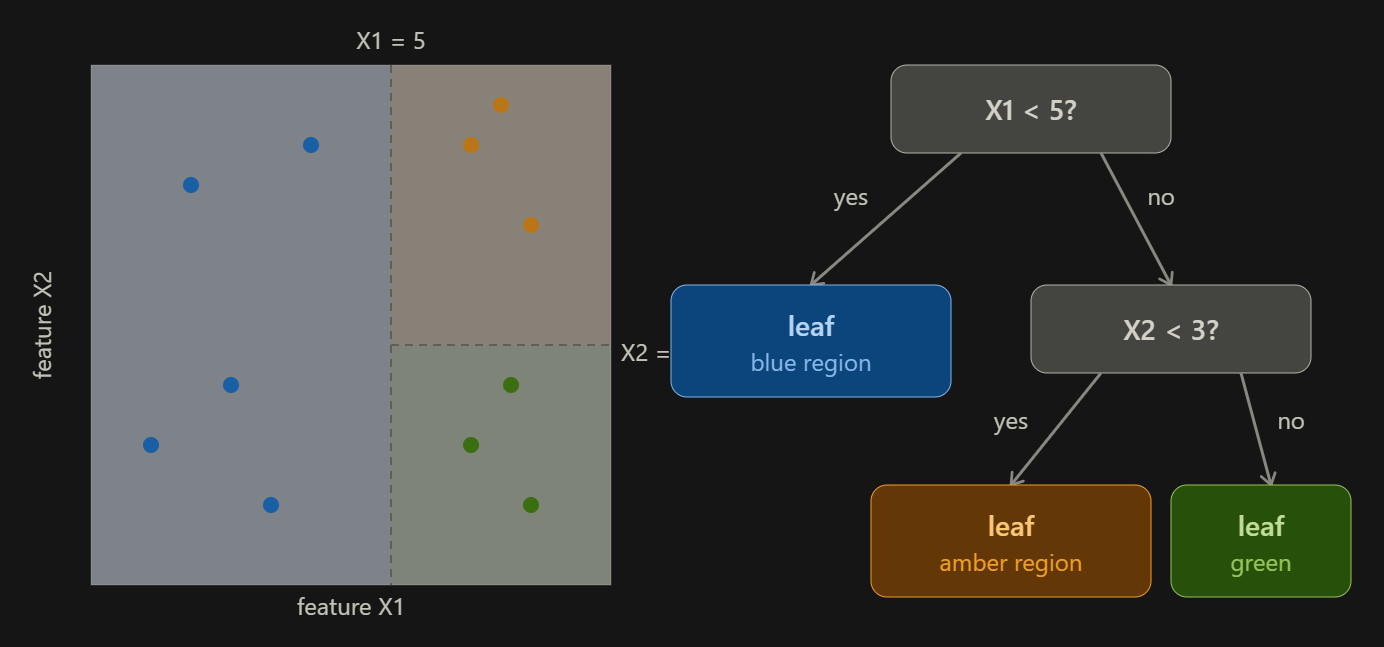

Each such question is a single cut, perpendicular to one axis, through the feature space. As you go deeper in the tree, you keep slicing the space into smaller boxes (rectangles in 2D, hyper-rectangles in higher dimensions).Each split is a straight, axis-aligned line (never diagonal), so a tree's decision boundary is always a union of rectangles. This is both its strength (interpretable, no scaling needed) and its weakness — it can't efficiently represent a diagonal boundary without many small steps, unlike an SVM's smooth curved boundary.

## 2. How a split is chosen: impurity

At any node, the tree tries every feature and every threshold, and picks the one that makes the two child nodes as "pure" (single-class) as possible. "Impurity" is the formal way of measuring how mixed a node's classes are. Two common measures:

### Entropy (information-theoretic)

For a node with classes having proportions p₁, p₂, ..., pₖ:

**H = −∑ pᵢ log₂(pᵢ)**

- If a node is pure (all one class, say p₁ = 1): H = 0 — no uncertainty.
- If a node is a perfect 50/50 split of two classes: H = −(0.5·log₂0.5 + 0.5·log₂0.5) = 1 — maximum uncertainty.
- Entropy comes from information theory: it's the expected number of bits needed to identify the class of a random sample from that node. A pure node needs zero bits (you already know the answer); a 50/50 node needs a full bit.

### Gini impurity

**Gini = 1 − ∑ pᵢ²**

- Interpretation: the probability of misclassifying a randomly chosen sample if you labeled it randomly according to the node's class distribution.
- Pure node: Gini = 0. Two-class 50/50 node: Gini = 1 − (0.25+0.25) = 0.5.
- Computationally cheaper than entropy (no logarithms), and in practice gives very similar trees. Gini is scikit-learn's default (`criterion='gini'`); entropy is the alternative (`criterion='entropy'`).

Both measures agree on the extremes (0 for pure, max at balanced classes) and usually rank candidate splits similarly — entropy is just slightly more sensitive to small shifts in class balance.

## 3. Information gain: choosing the best split

Once you have an impurity measure, **information gain** tells you how much a candidate split reduces impurity:

**IG = Impurity(parent) − [ (n_left/n) · Impurity(left) + (n_right/n) · Impurity(right) ]**

That is: the parent's impurity, minus the weighted average impurity of the children (weighted by how many samples fall into each). The algorithm:

1. At each node, loop over every feature and every possible threshold.
2. For each candidate split, compute the weighted child impurity and thus the information gain.
3. Pick the (feature, threshold) pair with the **highest** information gain.
4. Recurse on each child, repeating until a stopping condition is met (pure node, max depth, minimum samples per leaf, etc.).

**Worked mini-example:** suppose a parent node has 10 samples, 5 of each class (Gini = 0.5). A split sends 6 samples to the left child (5 of class A, 1 of class B → Gini = 1 − (5/6)² − (1/6)² ≈ 0.278) and 4 to the right (0 of A, 4 of B → Gini = 0, pure).

Weighted child impurity = (6/10)(0.278) + (4/10)(0) ≈ 0.167
Information gain = 0.5 − 0.167 = **0.333**

The tree would compare this gain against every other candidate split (different feature, different threshold) and take the one with the largest value.

## 4. Why this all matters together

- **Entropy/Gini** answer "how mixed is this group?"
- **Information gain** answers "which question best separates the mixing?"
- **Geometrically**, maximizing information gain at each step is equivalent to choosing the axis-aligned cut that carves the cleanest-possible rectangle out of the remaining space.
- Left unchecked, a tree will keep splitting until every leaf is pure (often just one point per leaf) — this is how decision trees overfit, since a lone outlier can get its own tiny rectangle. That's why `max_depth`, `min_samples_leaf`, and pruning exist: they stop the geometric carving before it starts memorizing noise.